### Plant Disease Detection  system using CNN

https://www.kaggle.com/datasets/mohitsingh1804/plantvillage

# about my data set

Context
PlantVillage dataset containing 38 classes of plants with around 54,303 images

Content
Plant Village dataset is a public dataset of 54,305 images of diseased and healthy plant leaves collected under controlled conditions ( PlantVillage Dataset). The images cover 14 species of crops, including: apple, blueberry, cherry, grape, orange, peach, pepper, potato, raspberry, soy, squash, strawberry and tomato. It contains images of 17 basic diseases, 4 bacterial diseases, 2 diseases caused by mold (oomycete), 2 viral diseases and 1 disease caused by a mite. 12 crop species also have healthy leaf images that are not visibly affected by disease.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
import json

kaggle_info = {
    "username": "ravikr7488",
    "key": "KGAT_f78ff8488fd934eb51009fa495ab18a1"
}

with open("/content/kaggle.json", "w") as f:
    json.dump(kaggle_info, f)

In [3]:
!pip install -q kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d mohitsingh1804/plantvillage

Dataset URL: https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
License(s): GPL-2.0
100% 818M/818M [00:08<00:00, 104MB/s]



In [6]:
!unzip plantvillage.zip

Streaming output truncated to the last 5000 lines.
  inflating: PlantVillage/val/Soybean___healthy/52c7d07b-561b-4380-801a-3824e65a5135___RS_HL 3797.JPG  
  inflating: PlantVillage/val/Soybean___healthy/53168d1c-ac90-4039-9eff-7479475a6b74___RS_HL 6355.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5344b09f-bbbe-4a2c-9345-d93dd4e69eb4___RS_HL 4693.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5361ba4a-351e-466c-99c5-8845f35c00df___RS_HL 2890.JPG  
  inflating: PlantVillage/val/Soybean___healthy/537e5409-d824-4859-967f-3c502f13deec___RS_HL 5474.JPG  
  inflating: PlantVillage/val/Soybean___healthy/538969da-545b-4bce-bc1d-0932898dc5e6___RS_HL 5230.JPG  
  inflating: PlantVillage/val/Soybean___healthy/538ccfe2-1509-40d7-beae-ae7cf84e1e5d___RS_HL 3717.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5397bf6a-aeeb-4f1c-b554-bdb604bb23c3___RS_HL 6508.JPG  
  inflating: PlantVillage/val/Soybean___healthy/53dc0466-621c-43e1-9c5e-e340f3d50171___RS_HL 6381.JPG  
  inflating: 

In [7]:
train_dir='/content/PlantVillage/train'

In [8]:
IMG_SIZE=(224,224)
BATCH_SIZE=32

In [9]:
train_ds=image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='training'
)

val_ds=image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123,
    validation_split=0.2,
    subset='validation'

)


Found 43444 files belonging to 38 classes.
Using 34756 files for training.
Found 43444 files belonging to 38 classes.
Using 8688 files for validation.


In [10]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [11]:
for i ,l in train_ds.take(1):
  print(i[0].shape)
  print(l[0])

(224, 224, 3)
tf.Tensor(24, shape=(), dtype=int32)


In [12]:
class_name=train_ds.class_names

In [83]:
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [62]:
# auguments=tf.keras.Sequential([
#     layers.RandomFlip('horizontal'),
#     layers.RandomRotation(0.2),
#     layers.RandomZoom(0.2),

# ])

In [84]:
CNN=Sequential([
    layers.Input(shape=(224,224,3)),  # input layer now at the beginning
    # auguments, # fliiping performed
    layers.Rescaling(1./255), # input_shape removed as it's defined in the Input layer

    layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Conv2D(128, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(class_name), activation='softmax')  # output layers

])

In [85]:
CNN.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [86]:
CNN.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 72s 63ms/step - accuracy: 0.5201 - loss: 1.7258 - val_accuracy: 0.7587 - val_loss: 0.7979
Epoch 2/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 78s 61ms/step - accuracy: 0.7118 - loss: 0.9383 - val_accuracy: 0.8363 - val_loss: 0.5514
Epoch 3/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 66s 61ms/step - accuracy: 0.7765 - loss: 0.7031 - val_accuracy: 0.8690 - val_loss: 0.4324
Epoch 4/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 66s 61ms/step - accuracy: 0.8269 - loss: 0.5480 - val_accuracy: 0.8766 - val_loss: 0.4075
Epoch 5/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 68s 63ms/step - accuracy: 0.8518 - loss: 0.4486 - val_accuracy: 0.8672 - val_loss: 0.4432
Epoch 6/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 67s 61ms/step - accuracy: 0.8766 - loss: 0.3732 - val_accuracy: 0.8919 - val_loss: 0.3685
Epoch 7/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 67s 61ms/step - accuracy: 0.8883 - loss: 0.3330 - val_accuracy: 0.9010 - val_loss: 0.3241
Epoch 8/10
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.9090 -

### now after traning it give 91% and tesing 90% accuracy





### here take new test data

In [89]:
test_dir='/content/PlantVillage/val'

In [90]:
test_ds=image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    )

Found 10861 files belonging to 38 classes.


In [91]:
CNN.evaluate(test_ds)

340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9131 - loss: 0.3117


[0.3116931915283203, 0.9130834937095642]

In [93]:
test='/content/PlantVillage/val/Apple___healthy/04125537-801d-4e15-b66c-224b09b4e1a7___RS_HL 7457.JPG'

In [35]:
# def load_image(img_path, show=False):
#     img=image.load_img(img_path, target_size=(224,224))
#     img_tensor=image.img_to_array(img)
#     img_tensor=np.expand_dims(img_tensor, axis=0)
#     img_tensor/=255.
#     if show:
#         plt.imshow(img_tensor[0])
#         plt.axis('off')
#         plt.show()


In [49]:
# load_image(test)

In [94]:
img=image.load_img(test, target_size=(224,224))

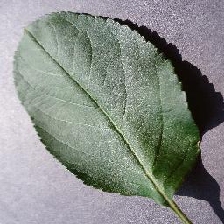

In [95]:
img

In [96]:
img_arry=image.img_to_array(img)

In [53]:
img_arry

array([[[187., 183., 197.],
        [188., 184., 198.],
        [191., 187., 201.],
        ...,
        [138., 131., 147.],
        [138., 131., 147.],
        [147., 140., 156.]],

       [[181., 177., 191.],
        [185., 181., 195.],
        [191., 187., 201.],
        ...,
        [135., 128., 144.],
        [138., 131., 147.],
        [155., 148., 164.]],

       [[191., 187., 201.],
        [194., 190., 204.],
        [197., 193., 207.],
        ...,
        [148., 141., 157.],
        [130., 123., 139.],
        [135., 128., 144.]],

       ...,

       [[189., 187., 201.],
        [191., 189., 203.],
        [193., 191., 205.],
        ...,
        [102.,  98., 112.],
        [ 27.,  23.,  37.],
        [ 37.,  33.,  47.]],

       [[196., 194., 208.],
        [194., 192., 206.],
        [190., 188., 202.],
        ...,
        [131., 127., 141.],
        [ 48.,  44.,  58.],
        [ 25.,  21.,  35.]],

       [[210., 208., 222.],
        [201., 199., 213.],
        [191., 1

In [97]:
img_arry.shape

(224, 224, 3)

In [98]:
img_arry=np.expand_dims(img_arry,axis=0)
print(img_arry.shape)

(1, 224, 224, 3)


In [99]:
pre=CNN.predict(img_arry)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step


In [100]:
class_name[pre.argmax()]

'Apple___healthy'

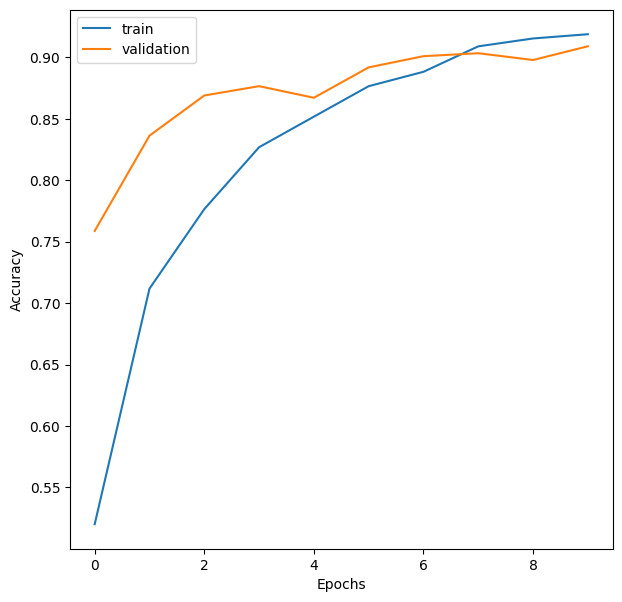

In [101]:
plt.figure(figsize=(7,7))
plt.plot(CNN.history.history['accuracy'])
plt.plot(CNN.history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train','validation'])
plt.show()

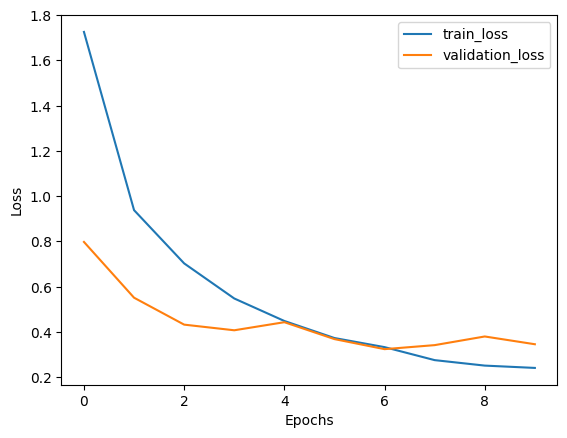

In [102]:
plt.plot(CNN.history.history['loss'])
plt.plot(CNN.history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train_loss','validation_loss'])
plt.show()

In [107]:
CNN.save("cnn_model.keras")